In [3]:
# # Task 5 — Deep Learning / NLP Text Classifier

# ## Sentiment Analysis using PyTorch

# This notebook implements a binary sentiment classifier using:

# - NLTK Movie Reviews dataset
# - Text tokenization
# - Vocabulary and integer encoding
# - PyTorch Embedding
# - Multi-layer Neural Network
# - Batch Normalization
# - Dropout
# - Early Stopping
# - Training and validation curves
# - Sample inference with classification confidence

In [4]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk

from collections import Counter

from nltk.corpus import movie_reviews

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [5]:
nltk.download("movie_reviews")

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


True

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [8]:
documents = []

for category in movie_reviews.categories():
    label = 1 if category == "pos" else 0

    for fileid in movie_reviews.fileids(category):
        words = movie_reviews.words(fileid)
        text = " ".join(words)

        documents.append({
            "text": text,
            "label": label
        })

df = pd.DataFrame(documents)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 2)


,text,label
0,"plot : two teen couples go to a church party ,...",0
1,the happy bastard ' s quick movie review damn ...,0
2,it is movies like these that make a jaded movi...,0
3,""" quest for camelot "" is warner bros . ' first...",0
4,synopsis : a mentally unstable man undergoing ...,0


In [9]:
print("Class distribution:")

print(
    df["label"]
    .value_counts()
    .rename(index={
        0: "Negative",
        1: "Positive"
    })
)

Class distribution:
label
Negative    1000
Positive    1000
Name: count, dtype: int64


In [10]:
def tokenize(text):
    text = text.lower()

    tokens = re.findall(
        r"\b[a-z]+\b",
        text
    )

    return tokens


sample_text = "This movie was absolutely fantastic!"

print("Original:")
print(sample_text)

print("\nTokens:")
print(tokenize(sample_text))

Original:
This movie was absolutely fantastic!

Tokens:
['this', 'movie', 'was', 'absolutely', 'fantastic']


In [11]:
df["tokens"] = df["text"].apply(tokenize)

df[["text", "tokens", "label"]].head()

,text,tokens,label
0,"plot : two teen couples go to a church party ,...","[plot, two, teen, couples, go, to, a, church, ...",0
1,the happy bastard ' s quick movie review damn ...,"[the, happy, bastard, s, quick, movie, review,...",0
2,it is movies like these that make a jaded movi...,"[it, is, movies, like, these, that, make, a, j...",0
3,""" quest for camelot "" is warner bros . ' first...","[quest, for, camelot, is, warner, bros, first,...",0
4,synopsis : a mentally unstable man undergoing ...,"[synopsis, a, mentally, unstable, man, undergo...",0


In [12]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Training samples: 1600
Validation samples: 200
Test samples: 200


In [13]:
MAX_VOCAB_SIZE = 5000

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

word_counter = Counter()

for tokens in train_df["tokens"]:
    word_counter.update(tokens)

most_common_words = word_counter.most_common(
    MAX_VOCAB_SIZE - 2
)

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, _ in most_common_words:
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 5000


In [14]:
print("First 30 vocabulary entries:")

for word, index in list(vocab.items())[:30]:
    print(index, "->", word)

First 30 vocabulary entries:
0 -> <PAD>
1 -> <UNK>
2 -> the
3 -> a
4 -> and
5 -> of
6 -> to
7 -> is
8 -> in
9 -> s
10 -> it
11 -> that
12 -> as
13 -> with
14 -> for
15 -> this
16 -> his
17 -> film
18 -> he
19 -> i
20 -> but
21 -> on
22 -> are
23 -> t
24 -> by
25 -> be
26 -> one
27 -> an
28 -> movie
29 -> who


In [15]:
def encode_tokens(tokens, vocab):
    return [
        vocab.get(token, vocab[UNK_TOKEN])
        for token in tokens
    ]


sample_tokens = tokenize(
    "This movie was excellent"
)

sample_ids = encode_tokens(
    sample_tokens,
    vocab
)

print("Tokens:")
print(sample_tokens)

print("\nInteger IDs:")
print(sample_ids)

Tokens:
['this', 'movie', 'was', 'excellent']

Integer IDs:
[15, 28, 34, 736]


In [16]:
MAX_LENGTH = 200


def pad_sequence(sequence, max_length=MAX_LENGTH):
    if len(sequence) > max_length:
        return sequence[:max_length]

    return sequence + [vocab[PAD_TOKEN]] * (
        max_length - len(sequence)
    )

In [17]:
def prepare_data(dataframe):
    encoded_sequences = []

    labels = []

    for _, row in dataframe.iterrows():

        tokens = row["tokens"]

        sequence = encode_tokens(
            tokens,
            vocab
        )

        sequence = pad_sequence(
            sequence
        )

        encoded_sequences.append(sequence)

        labels.append(row["label"])

    return (
        np.array(
            encoded_sequences,
            dtype=np.int64
        ),
        np.array(
            labels,
            dtype=np.int64
        )
    )


X_train, y_train = prepare_data(train_df)
X_val, y_val = prepare_data(val_df)
X_test, y_test = prepare_data(test_df)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (1600, 200)
X_val: (200, 200)
X_test: (200, 200)


In [18]:
class SentimentDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.long
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):

        return (
            self.X[index],
            self.y[index]
        )

In [19]:
BATCH_SIZE = 32

train_dataset = SentimentDataset(
    X_train,
    y_train
)

val_dataset = SentimentDataset(
    X_val,
    y_val
)

test_dataset = SentimentDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [20]:
class SentimentClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_classes=2,
        dropout=0.5
    ):

        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=vocab[PAD_TOKEN]
        )

        # First fully connected layer
        self.fc1 = nn.Linear(
            embedding_dim,
            hidden_dim
        )

        # Batch Normalization
        self.batch_norm = nn.BatchNorm1d(
            hidden_dim
        )

        # Dropout
        self.dropout = nn.Dropout(
            dropout
        )

        # Output layer
        self.fc2 = nn.Linear(
            hidden_dim,
            num_classes
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        # x shape:
        # [batch_size, sequence_length]

        embedded = self.embedding(x)

        # Create mask for padding tokens
        mask = (
            x != vocab[PAD_TOKEN]
        ).unsqueeze(-1)

        # Convert mask to float
        mask = mask.float()

        # Sum valid embeddings
        summed_embeddings = (
            embedded * mask
        ).sum(dim=1)

        # Number of valid tokens
        token_count = mask.sum(
            dim=1
        ).clamp(min=1)

        # Mean pooling
        pooled = (
            summed_embeddings /
            token_count
        )

        # Fully connected layer
        x = self.fc1(pooled)

        # Batch normalization
        x = self.batch_norm(x)

        # ReLU
        x = self.relu(x)

        # Dropout
        x = self.dropout(x)

        # Output
        x = self.fc2(x)

        return x

In [21]:
model = SentimentClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    num_classes=2,
    dropout=0.5
)

model = model.to(device)

print(model)

SentimentClassifier(
  (embedding): Embedding(5000, 128, padding_idx=0)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)


In [22]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [23]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item() *
            X_batch.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    epoch_loss = (
        total_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [24]:
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            total_loss += (
                loss.item() *
                X_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                y_batch.cpu().numpy()
            )

    epoch_loss = (
        total_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy,
        all_predictions,
        all_labels
    )

In [25]:
NUM_EPOCHS = 15
PATIENCE = 3

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
patience_counter = 0

best_model_state = None


for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # Early stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        best_model_state = {
            key: value.cpu().clone()
            for key, value
            in model.state_dict().items()
        }

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print(
                "\nEarly stopping triggered."
            )

            break

Epoch 1/15 | Train Loss: 0.7241 | Train Acc: 0.5250 | Val Loss: 0.6860 | Val Acc: 0.5700
Epoch 2/15 | Train Loss: 0.6498 | Train Acc: 0.6175 | Val Loss: 0.7365 | Val Acc: 0.5200
Epoch 3/15 | Train Loss: 0.6084 | Train Acc: 0.6713 | Val Loss: 0.6966 | Val Acc: 0.5650
Epoch 4/15 | Train Loss: 0.5598 | Train Acc: 0.6981 | Val Loss: 0.7254 | Val Acc: 0.5900

Early stopping triggered.


In [26]:
if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )

    model = model.to(device)

print("Best model restored successfully.")

Best model restored successfully.


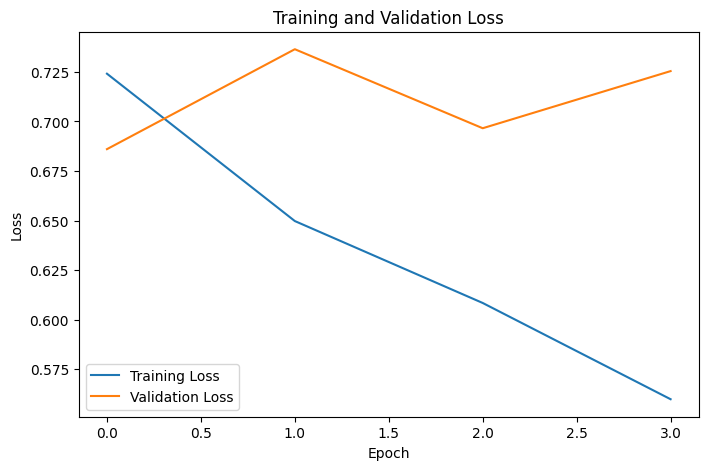

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.show()

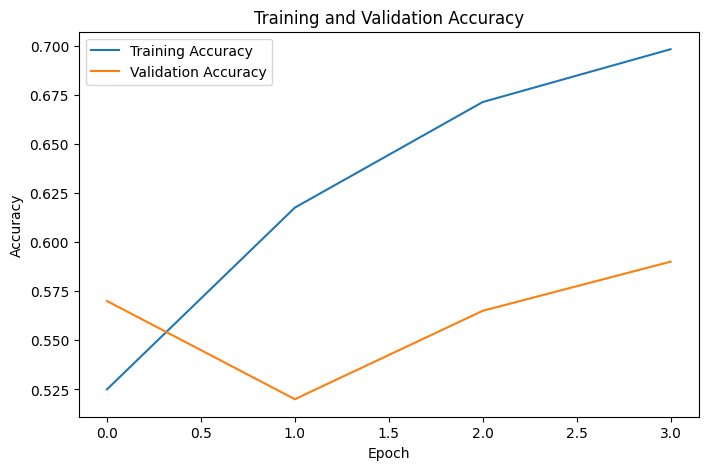

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.show()

In [29]:
test_loss, test_accuracy, test_predictions, test_labels = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

Test Loss: 0.6849
Test Accuracy: 0.5450


In [30]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.53      0.80      0.64       100
    Positive       0.59      0.29      0.39       100

    accuracy                           0.55       200
   macro avg       0.56      0.55      0.51       200
weighted avg       0.56      0.55      0.51       200



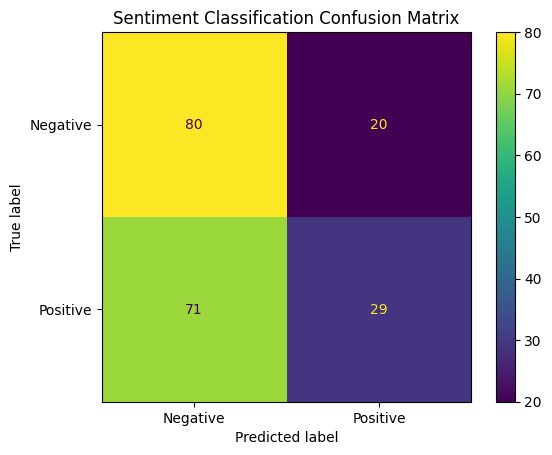

In [31]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot()

plt.title(
    "Sentiment Classification Confusion Matrix"
)

plt.show()

In [32]:
def predict_sentiment(
    text,
    model,
    vocab,
    device,
    max_length=MAX_LENGTH
):

    model.eval()

    tokens = tokenize(text)

    sequence = encode_tokens(
        tokens,
        vocab
    )

    sequence = pad_sequence(
        sequence,
        max_length
    )

    input_tensor = torch.tensor(
        [sequence],
        dtype=torch.long
    ).to(device)

    with torch.no_grad():

        outputs = model(
            input_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    label = (
        "Positive"
        if prediction.item() == 1
        else "Negative"
    )

    return (
        label,
        confidence.item()
    )

In [33]:
sample = (
    "This movie was absolutely fantastic "
    "and I really enjoyed watching it."
)

label, confidence = predict_sentiment(
    sample,
    model,
    vocab,
    device
)

print("Text:", sample)
print("Prediction:", label)
print(
    f"Confidence: {confidence * 100:.2f}%"
)

Text: This movie was absolutely fantastic and I really enjoyed watching it.
Prediction: Negative
Confidence: 75.77%


In [34]:
samples = [
    "I really loved this movie. It was excellent.",
    "This movie was boring and disappointing.",
    "The acting was fantastic and the story was amazing.",
    "I hated this movie. It was terrible.",
    "The movie was enjoyable and entertaining."
]

for text in samples:

    label, confidence = predict_sentiment(
        text,
        model,
        vocab,
        device
    )

    print("=" * 70)

    print("Text:", text)

    print("Prediction:", label)

    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

Text: I really loved this movie. It was excellent.
Prediction: Negative
Confidence: 63.22%
Text: This movie was boring and disappointing.
Prediction: Negative
Confidence: 59.70%
Text: The acting was fantastic and the story was amazing.
Prediction: Positive
Confidence: 59.95%
Text: I hated this movie. It was terrible.
Prediction: Negative
Confidence: 83.35%
Text: The movie was enjoyable and entertaining.
Prediction: Negative
Confidence: 67.54%


In [35]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "vocab": vocab,
        "max_length": MAX_LENGTH
    },
    "sentiment_classifier_pytorch.pth"
)

print(
    "Model saved successfully!"
)

Model saved successfully!


# Conclusion

The Deep Learning NLP pipeline was successfully implemented using PyTorch.

The project demonstrated:

- Text tokenization
- Vocabulary creation
- Integer encoding
- Sequence padding
- PyTorch Embedding
- Multi-layer neural network
- Batch Normalization
- ReLU activation
- Dropout
- Training and validation
- Early stopping
- Loss convergence visualization
- Accuracy convergence visualization
- Test-set evaluation
- Confusion matrix
- Unseen text inference
- Classification confidence

The final model can classify new movie reviews as Positive or Negative and provide a confidence score for the prediction.

## Dataset Limitation

The model is intended as an educational demonstration of an NLP Deep Learning pipeline. Performance should not be interpreted as production-level sentiment analysis because the dataset and model architecture are relatively limited compared with modern Transformer-based NLP systems.